# 02 - Calculer une empreinte environnementale nationale

Ce notebook relie les pressions environnementales à la structure économique étudiée dans le notebook `01`. À la fin, vous saurez :

- distinguer une pression physique d’un impact caractérisé ;
- calculer des émissions associées à la production et à la consommation ;
- intégrer les émissions directes de la demande finale ;
- vérifier l’identité entre production, importations, exportations et consommation ;
- décomposer une empreinte selon le lieu et l’industrie d’origine ;
- appliquer la même méthode à une empreinte matière.

## 1. Deux points de vue complémentaires

Une empreinte nationale peut être étudiée selon deux principes comptables :

- le compte fondé sur la production attribue les pressions au pays dans lequel elles sont générées ;
- le compte fondé sur la consommation attribue les pressions au pays dont la demande finale les provoque, même lorsque la production a lieu à l’étranger.

Dans PyMRIO, ces comptes sont respectivement nommés `D_pba` (*production-based account*) et `D_cba` (*consumption-based account*). Les pressions incorporées dans les importations et exportations sont disponibles dans `D_imp` et `D_exp`.

## 2. Charger et calculer EXIOBASE

Comme les notebooks précédents, celui-ci recharge directement l’archive vérifiée dans le notebook `00`. Nous calculons le cœur économique, puis seulement les deux extensions utiles ici : émissions atmosphériques et matières.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymrio as mr

ANNEE = 2022
SYSTEME = "ixi"
DOSSIER_EXIOBASE = Path("D:/EXIOBASE/3.10.2")
ARCHIVE_EXIOBASE = DOSSIER_EXIOBASE / f"IOT_{ANNEE}_{SYSTEME}.zip"

if not ARCHIVE_EXIOBASE.exists():
    raise FileNotFoundError(
        f"Archive absente : {ARCHIVE_EXIOBASE}. "
        "Exécutez d’abord le notebook 00_préparer_EXIOBASE.ipynb."
    )

In [3]:
io = mr.parse_exiobase3(path=ARCHIVE_EXIOBASE)
_ = io.calc_system()

colonnes_production_nulle = io.x.iloc[:, 0].eq(0)
for nom_extension in ("air_emissions", "material"):
    extension = getattr(io, nom_extension)
    extension.S = mr.calc_S(extension.F, io.x).fillna(0)
    _ = extension.calc_system(x=io.x, Y=io.Y, L=io.L)

print("EXIOBASE chargée et extensions environnementales calculées.")

EXIOBASE chargée et extensions environnementales calculées.


### Un cas particulier de la version 3.10.2

Certaines colonnes ont une production monétaire nulle, mais une pression environnementale non nulle. Leur intensité $S = F/x$ est donc indéfinie. PyMRIO la représente initialement par `NaN`, ce qui empêcherait les calculs matriciels.

Nous adoptons une convention explicite : l’intensité de ces colonnes est fixée à zéro. Leurs pressions restent présentes dans $F$ et dans le compte de production observé, mais elles ne sont pas propagées dans les empreintes de consommation. Nous en mesurerons l’importance au lieu de les masquer. Cette convention est surtout importante pour l’empreinte matière.

In [4]:
pd.Series(
    {
        "colonnes à production nulle": colonnes_production_nulle.sum(),
        "avec au moins une émission atmosphérique": (
            io.air_emissions.F.loc[:, colonnes_production_nulle]
            .fillna(0)
            .ne(0)
            .any(axis=0)
            .sum()
        ),
        "avec au moins une extraction de matière": (
            io.material.F.loc[:, colonnes_production_nulle]
            .fillna(0)
            .ne(0)
            .any(axis=0)
            .sum()
        ),
    },
    name="nombre de colonnes",
)

colonnes à production nulle                 1866
avec au moins une émission atmosphérique     809
avec au moins une extraction de matière       33
Name: nombre de colonnes, dtype: int64

## 3. Relier l’économie et l’environnement

Chaque extension environnementale contient plusieurs matrices :

| Objet | Signification |
|---|---|
| `F` | pressions directes des industries |
| `F_Y` | pressions directes de la demande finale, par exemple la combustion de carburant par les ménages |
| `S` | pression directe par unité de production |
| `M = SL` | pression directe et indirecte par unité de demande finale |
| `D_pba` | compte fondé sur la production |
| `D_cba` | compte fondé sur la consommation |
| `D_imp`, `D_exp` | pressions incorporées dans les importations et les exportations |

Les lignes correspondent à des substances ou des ressources physiques. Les colonnes correspondent aux régions et industries, ou aux catégories de demande finale pour `F_Y`.

In [6]:
pd.DataFrame(
    {
        "extension": list(io.get_extensions()),
        "nombre de pressions": [
            len(getattr(io, nom).get_rows()) for nom in io.get_extensions()
        ],
    }
)

,extension,nombre de pressions
0,land,26
1,material,62
2,factor_inputs,9
3,employment,12
4,air_emissions,420
5,water,194
6,energy,4
7,nutrients,6


### Pression physique et impact caractérisé

Une émission de CO2, une émission de CH4 et une extraction de cuivre sont des **pressions physiques**. On ne peut pas les additionner directement.

Un **facteur de caractérisation** convertit plusieurs pressions vers un indicateur commun. Pour le changement climatique, le potentiel de réchauffement global à 100 ans, ou PRG100, exprime les gaz en kilogrammes équivalent CO2. Le choix de la méthode et de sa version fait partie du périmètre de l’étude.

In [7]:
gaz_recherches = ("CO2", "CH4", "N2O", "SF6", "HFC", "PFC")
lignes_gaz = [
    ligne
    for ligne in io.air_emissions.get_rows()
    if str(ligne).startswith(gaz_recherches)
]
io.air_emissions.unit.loc[lignes_gaz]

,unit
stressor,
CH4 - combustion - air,kg
CH4_bio - combustion - air,kg
CO2 - combustion - air,kg
CO2_bio - combustion - air,kg
N2O - combustion - air,kg
N2O_bio - combustion - air,kg
CH4 - non combustion - Extraction/production of (natural) gas - air,kg
CH4 - non combustion - Extraction/production of crude oil - air,kg
CH4 - non combustion - Mining of antracite - air,kg


## 4. Construire un indicateur climatique

Nous utilisons les PRG100 du sixième rapport d’évaluation du GIEC :

- CO2 fossile : 1 ;
- CH4 biogénique ou issu de la combustion : 27,0 ;
- CH4 fossile fugitif ou de procédé : 29,8 ;
- N2O : 273 ;
- SF6 : 25 200.

Source : GIEC, AR6, groupe de travail I, chapitre 7, tableau 7.15, <https://www.ipcc.ch/report/ar6/wg1/chapter/chapter-7/>.

Les lignes `HFC - air` et `PFC - air` d’EXIOBASE regroupent plusieurs gaz dont les PRG diffèrent. Faute de composition détaillée dans ces lignes agrégées, elles ne sont pas caractérisées ici. Le résultat est donc un indicateur climatique documenté, mais il ne doit pas être présenté comme un inventaire exhaustif de tous les gaz fluorés. Le CO2 biogénique est également laissé hors du total.

In [36]:
index_emissions = io.air_emissions.F.index
facteurs_prg100 = pd.Series(0.0, index=index_emissions, name="PRG100")
noms_emissions = index_emissions.to_series().astype(str)

masque_co2_fossile = (
    noms_emissions.str.startswith("CO2 -")
    & ~noms_emissions.str.contains("biogenic", case=False)
)
masque_methane = noms_emissions.str.startswith(("CH4 -", "CH4_bio -"))
masque_methane_fossile = noms_emissions.str.contains(
    "Extraction/production|Mining of|Oil refinery", regex=True
)
masque_n2o = noms_emissions.str.startswith(("N2O -", "N2O_bio -"))
masque_prg = io.air_emissions.unit["unit"]=="kg CO2-eq"

facteurs_prg100.loc[masque_co2_fossile] = 1.0
facteurs_prg100.loc[masque_prg] = 1.0 # ces émissions sont déjà exprimées en équivalent CO2
facteurs_prg100.loc[masque_methane] = 27.0
facteurs_prg100.loc[masque_methane & masque_methane_fossile] = 29.8
facteurs_prg100.loc[masque_n2o] = 273.0
if "SF6 - air" in facteurs_prg100.index:
    facteurs_prg100.loc["SF6 - air"] = 25_200.0

facteurs_prg100[facteurs_prg100.ne(0)].to_frame()

,PRG100
stressor,
CH4 - combustion - air,27.0
CH4_bio - combustion - air,27.0
CO2 - combustion - air,1.0
N2O - combustion - air,273.0
N2O_bio - combustion - air,273.0
CH4 - non combustion - Extraction/production of (natural) gas - air,29.8
CH4 - non combustion - Extraction/production of crude oil - air,29.8
CH4 - non combustion - Mining of antracite - air,29.8
CH4 - non combustion - Mining of bituminous coal - air,29.8


Le produit matriciel du vecteur de PRG100 par une matrice d’émissions transforme ses lignes exprimées en kilogrammes de gaz en une ligne exprimée en kilogrammes équivalent CO2. Par exemple :

$$F_{climat} = q_{PRG100} F_{air}$$

In [37]:
emissions_industries = facteurs_prg100 @ io.air_emissions.F
emissions_demande_finale = facteurs_prg100 @ io.air_emissions.F_Y

pd.Series(
    {
        "émissions directes des industries (Mt CO2e)": (
            emissions_industries.sum() * 1e-9
        ),
        "émissions directes de la demande finale (Mt CO2e)": (
            emissions_demande_finale.sum() * 1e-9
        ),
    },
    name=f"Monde, {ANNEE}",
)

émissions directes des industries (Mt CO2e)          42966.432503
émissions directes de la demande finale (Mt CO2e)     4508.725718
Name: Monde, 2022, dtype: float64

Encore une fois, il est possible de vérifier le total, qui devrait être autour de 53.8 Gt CO2 eq. pour 2022 https://www.statistiques.developpement-durable.gouv.fr/emissions-de-gaz-effet-de-serre-et-empreinte-carbone-en-2022-synthese-des-connaissances-en-2023

Les émissions totales sont relativement sous-estimées à cause des émissions de CO2 biogéniques, comptées comme 0 ici, mais 1 dans les statistiques officielles comme la base JRC EDGAR (elles sont censées être partiellement compensées par le LULUCF).

In [38]:
(emissions_industries.sum() + emissions_demande_finale.sum()) * 1e-12

np.float64(47.47515822086119)

In [ ]:
# Avec les émissions de CO2 biogénique
(emissions_industries.sum() + emissions_demande_finale.sum()) * 1e-12 + \
(io.air_emissions.F.loc["CO2_bio - combustion - air"].sum() + io.air_emissions.F_Y.loc["CO2_bio - combustion - air"].sum())* 1e-12

np.float64(53.544307243647594)

In [39]:
climat_non_attribuable = emissions_industries.loc[
    colonnes_production_nulle
].sum()
matiere_par_colonne = io.material.F.fillna(0).sum(axis=0)
matiere_non_attribuable = matiere_par_colonne.loc[
    colonnes_production_nulle
].sum()

pd.Series(
    {
        "climat": 100 * climat_non_attribuable / emissions_industries.sum(),
        "matières": 100 * matiere_non_attribuable / matiere_par_colonne.sum(),
    },
    name="part non attribuable aux chaînes d’approvisionnement (%)",
).to_frame()

,part non attribuable aux chaînes d’approvisionnement (%)
climat,0.144258
matières,2.455601


## 5. Calculer les comptes nationaux

Les objets dont le nom se termine par `_reg` sont déjà agrégés par région. Nous caractérisons séparément :

- les émissions des industries dans `D_pba_reg` ;
- les émissions des chaînes d’approvisionnement de la demande finale dans `D_cba_reg` ;
- les émissions incorporées dans le commerce ;
- les émissions directes de la demande finale contenues dans `F_Y`.

Dans PyMRIO, `D_pba_reg` et `D_cba_reg` comprennent déjà les émissions directes de `F_Y`, par exemple la combustion de carburant dans les voitures des ménages. Nous les isolons pour information, sans les ajouter une seconde fois.

Nous distinguons aussi la production observée, calculée directement avec $F$, de la production attribuable aux chaînes d’approvisionnement après application de la convention sur les productions nulles. C’est cette seconde grandeur qui entre dans l’identité comptable du modèle.

In [50]:
emissions_production_attribuable = (
    facteurs_prg100 @ io.air_emissions.D_pba_reg
)
empreinte_consommation = facteurs_prg100 @ io.air_emissions.D_cba_reg
emissions_importees = facteurs_prg100 @ io.air_emissions.D_imp_reg
emissions_exportees = facteurs_prg100 @ io.air_emissions.D_exp_reg
emissions_finales_par_region = emissions_demande_finale.groupby(
    level="region"
).sum()
emissions_consommation_amont = (
    empreinte_consommation - emissions_finales_par_region
)
emissions_production_observee = (
    emissions_industries.groupby(level="region").sum()
    + emissions_finales_par_region
)

comptes_climat = pd.DataFrame(
    {
        "production observée": emissions_production_observee,
        "production attribuable": emissions_production_attribuable,
        "consommation": empreinte_consommation,
        "importations": emissions_importees,
        "exportations": emissions_exportees,
        "émissions directes finales": emissions_finales_par_region,
    }
)
comptes_climat.index.name = "région"

### Exemple national : la France

Les résultats sont convertis de kilogrammes vers millions de tonnes équivalent CO2. Le solde net des importations correspond aux émissions importées moins les émissions exportées.

In [51]:
PAYS = "FR"
resultats_france = comptes_climat.loc[PAYS].copy()
resultats_france["solde net des importations"] = (
    resultats_france["importations"] - resultats_france["exportations"]
)
(resultats_france * 1e-9).rename("Mt CO2e").to_frame()

,Mt CO2e
production observée,409.751466
production attribuable,409.751466
consommation,611.224040
importations,329.264726
exportations,127.792152
émissions directes finales,118.424812
solde net des importations,201.472574


## 6. Vérifier l’identité comptable

À périmètre identique, le compte de consommation peut être obtenu à partir du compte de production attribuable :

$$empreinte = production + importations - exportations$$

Cette égalité doit être vérifiée numériquement pour chaque région.

In [52]:
empreinte_reconstituee = (
    emissions_production_attribuable
    + emissions_importees
    - emissions_exportees
)
ecart_identite = empreinte_reconstituee - empreinte_consommation

assert np.allclose(empreinte_reconstituee, empreinte_consommation)
pd.Series(
    {
        "écart maximal (kg CO2e)": ecart_identite.abs().max(),
        "écart pour la France (kg CO2e)": ecart_identite.loc[PAYS],
    },
    name="Contrôle production et consommation",
)

écart maximal (kg CO2e)           0.003906
écart pour la France (kg CO2e)    0.000122
Name: Contrôle production et consommation, dtype: float64

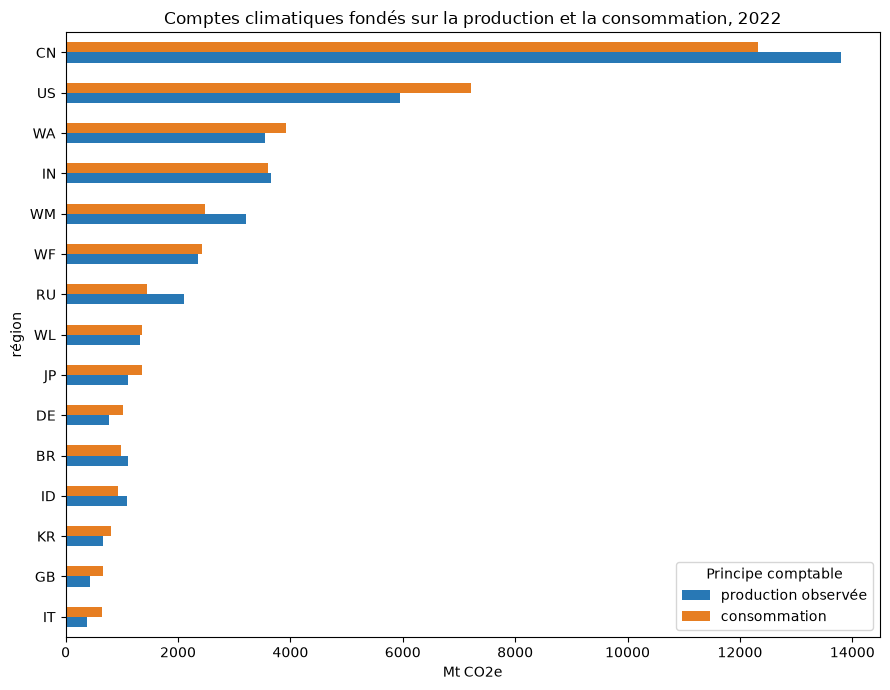

In [53]:
pays_a_afficher = empreinte_consommation.nlargest(15).index
comparaison_pays = (
    comptes_climat.loc[
        pays_a_afficher, ["production observée", "consommation"]
    ]
    * 1e-9
)

ax = comparaison_pays.sort_values("consommation").plot.barh(
    figsize=(9, 7), color=["#2878B5", "#E67E22"]
)
ax.set(
    title=f"Comptes climatiques fondés sur la production et la consommation, {ANNEE}",
    xlabel="Mt CO2e",
    ylabel="région",
)
ax.legend(title="Principe comptable")
plt.tight_layout()

### Peut-on appeler `D_pba` un inventaire territorial ?

Le compte fondé sur la production d’EXIOBASE constitue une approximation utile des émissions nationales, mais il ne coïncide pas nécessairement avec un inventaire territorial officiel. Les différences peuvent provenir du principe de résidence, du traitement des transports internationaux, des périmètres sectoriels, des sources statistiques, des gaz retenus et des facteurs de caractérisation.

Une comparaison à une statistique officielle doit donc commencer par harmoniser les périmètres, et pas seulement par comparer deux nombres.

## 7. Retrouver l’origine de l’empreinte française

Le compte national donne un total. Pour comprendre ce résultat, nous revenons au calcul matriciel :

1. la demande finale française $y_{FR}$ est extraite de $Y$ ;
2. $Ly_{FR}$ donne la production mobilisée dans chaque région et industrie ;
3. cette production est multipliée par l’intensité climatique directe $S_{climat}$.

Le résultat localise les émissions dans la chaîne d’approvisionnement. Les émissions directes de la demande finale restent présentées séparément.

In [54]:
demande_finale_france = io.Y[PAYS].sum(axis=1)
production_mobilisee_france = io.L @ demande_finale_france
intensite_climatique = facteurs_prg100 @ io.air_emissions.S
empreinte_amont_detaillee = intensite_climatique * production_mobilisee_france

assert np.isclose(
    empreinte_amont_detaillee.sum(), emissions_consommation_amont.loc[PAYS]
)

empreinte_par_region_origine = (
    empreinte_amont_detaillee.groupby(level="region").sum().sort_values(ascending=False)
)
empreinte_par_industrie_origine = (
    empreinte_amont_detaillee.groupby(level="sector").sum().sort_values(ascending=False)
)

In [55]:
pd.concat(
    {
        "principales régions d’origine": (
            empreinte_par_region_origine.head(12).reset_index(drop=True) * 1e-9
        ),
        "principales industries d’origine": (
            empreinte_par_industrie_origine.head(12).reset_index(drop=True) * 1e-9
        ),
    },
    axis=1,
).rename_axis(index="rang").rename(columns=lambda nom: "Mt CO2e")

,Mt CO2e,Mt CO2e
rang,,
0,163.534501,51.668361
1,50.600912,33.560414
2,29.229841,30.541223
3,25.579738,26.724937
4,25.345111,22.737546
5,23.930603,21.922450
6,14.771753,21.785349
7,13.572586,20.539944
8,13.066270,19.442859


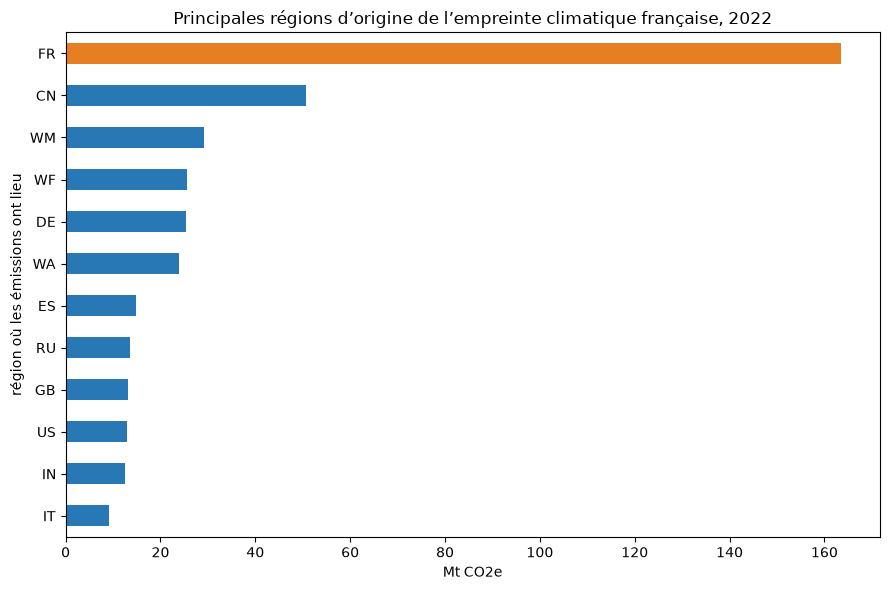

In [56]:
principales_origines = empreinte_par_region_origine.head(12).sort_values() * 1e-9
couleurs = ["#E67E22" if region == PAYS else "#2878B5" for region in principales_origines.index]

ax = principales_origines.plot.barh(figsize=(9, 6), color=couleurs)
ax.set(
    title=f"Principales régions d’origine de l’empreinte climatique française, {ANNEE}",
    xlabel="Mt CO2e",
    ylabel="région où les émissions ont lieu",
)
plt.tight_layout()

## 8. Reproduire la méthode pour l’empreinte matière

Une empreinte n’est pas nécessairement climatique. L’extension `material` comptabilise l’extraction intérieure utilisée de biomasse, minerais métalliques, minéraux non métalliques et combustibles fossiles. Toutes ses lignes sont exprimées en kilotonnes et peuvent donc être additionnées.

Depuis EXIOBASE 3.9, l’extraction inutilisée n’est plus incluse. L’indicateur calculé ici est donc une empreinte d’extraction intérieure **utilisée**, pas un besoin total en matières incluant les flux inutilisés.

La part associée aux colonnes de production nulle est conservée dans la production observée, mais ne peut pas être distribuée entre les demandes finales. La différence entre production observée et production attribuable la rend visible.

In [57]:
unites_matiere = io.material.unit["unit"].unique()
assert list(unites_matiere) == ["kt"]
print(
    f"{len(io.material.get_rows())} flux de matières, "
    f"tous exprimés en {unites_matiere[0]}."
)

62 flux de matières, tous exprimés en kt.


In [58]:
matiere_production_attribuable = io.material.D_pba_reg.sum(axis=0)
matiere_consommation = io.material.D_cba_reg.sum(axis=0)
matiere_importee = io.material.D_imp_reg.sum(axis=0)
matiere_exportee = io.material.D_exp_reg.sum(axis=0)
matiere_finale_par_region = (
    io.material.F_Y.fillna(0).sum(axis=0).groupby(level="region").sum()
)
matiere_production_observee = (
    matiere_par_colonne.groupby(level="region").sum()
    + matiere_finale_par_region
)

assert np.allclose(
    matiere_production_attribuable + matiere_importee - matiere_exportee,
    matiere_consommation,
)

comptes_matiere_france = pd.Series(
    {
        "production observée": matiere_production_observee.loc[PAYS],
        "production attribuable": matiere_production_attribuable.loc[PAYS],
        "consommation": matiere_consommation.loc[PAYS],
        "importations": matiere_importee.loc[PAYS],
        "exportations": matiere_exportee.loc[PAYS],
    },
    name="Mt",
) / 1_000
comptes_matiere_france.to_frame()

,Mt
production observée,747.877853
production attribuable,747.877853
consommation,1195.084765
importations,740.933767
exportations,293.726855


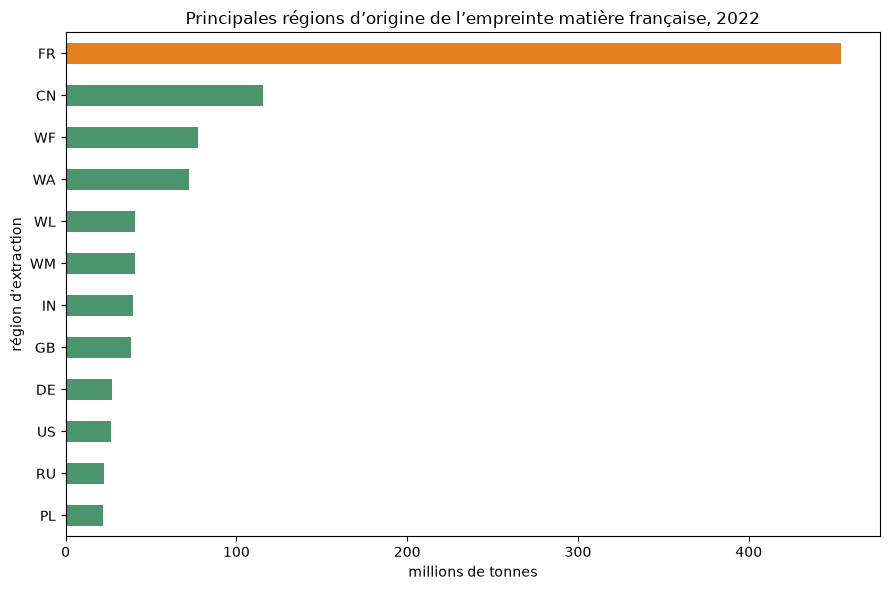

In [59]:
intensite_matiere = io.material.S.sum(axis=0)
empreinte_matiere_detaillee = intensite_matiere * production_mobilisee_france
empreinte_matiere_par_origine = (
    empreinte_matiere_detaillee.groupby(level="region").sum().sort_values(ascending=False)
)

assert np.isclose(
    empreinte_matiere_detaillee.sum(),
    matiere_consommation.loc[PAYS] - matiere_finale_par_region.loc[PAYS],
)

principales_origines_matiere = (
    empreinte_matiere_par_origine.head(12).sort_values() / 1_000
)
couleurs = [
    "#E67E22" if region == PAYS else "#4C956C"
    for region in principales_origines_matiere.index
]

ax = principales_origines_matiere.plot.barh(figsize=(9, 6), color=couleurs)
ax.set(
    title=f"Principales régions d’origine de l’empreinte matière française, {ANNEE}",
    xlabel="millions de tonnes",
    ylabel="région d’extraction",
)
plt.tight_layout()

## 9. Limites à documenter dans une analyse

Avant d’interpréter ou de présenter les résultats, il faut préciser :

- la version 3.10.2, le millésime 2022 et le système `ixi` ;
- le principe comptable retenu, production ou consommation ;
- l’inclusion des émissions directes de la demande finale ;
- les gaz retenus et les PRG100 utilisés ;
- l’exclusion des HFC et PFC agrégés dans cet exemple ;
- la convention appliquée aux secteurs dont la production monétaire est nulle ;
- les unités et facteurs de conversion ;
- les différences de périmètre avec les inventaires officiels ;
- les incertitudes et limites structurelles des modèles multirégionaux entrées-sorties.

## À retenir

- $F$ mesure les pressions directes et $S$ leur intensité économique ;
- $SLy$ relie une demande finale à toutes les pressions de sa chaîne d’approvisionnement ;
- une empreinte nationale inclut les pressions importées et exclut celles destinées aux exportations ;
- les pressions directes de la demande finale doivent être traitées explicitement ;
- un indicateur d’impact dépend toujours d’une méthode de caractérisation documentée ;
- la même architecture de calcul peut être utilisée pour le climat, les matières, l’eau ou l’utilisation des sols.